# Aurora SIGER — Fase 3: Operação Energética da Colônia

A colônia que pousou na Fase 2 agora **opera**. Este notebook narra os quatro
itens do enunciado da Fase 3 — organização hierárquica, regras de decisão,
previsão por regressão e análise energética — sobre um núcleo de simulação
**determinístico** (mesma seed ⇒ mesma história, hora a hora).

Toda a lógica vive em `aurora_siger.operations`; aqui apenas orquestramos e
visualizamos. O mesmo núcleo alimenta o dashboard TUI ao vivo (`aurora`).

## 0. Setup e simulação determinística

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from aurora_siger.operations.simulator import run_simulation
from aurora_siger.operations.constants import HOURS_PER_SOL

# Núcleo determinístico: mesma seed ⇒ história idêntica passo-a-passo.
climate, battery, history = run_simulation(seed=42)
n = len(history["total_generation_kw"])
print(f"Simulação: {n} horas ({n // HOURS_PER_SOL} sóis), seed=42 (determinística)")
print(f"Bateria final: {battery['current_charge_kwh']:.0f} / "
      f"{battery['max_capacity_kwh']:.0f} kWh "
      f"({battery['current_charge_kwh'] / battery['max_capacity_kwh'] * 100:.0f}%)")

Simulação: 168 horas (7 sóis), seed=42 (determinística)
Bateria final: 328 / 500 kWh (66%)


## Item 1.1 — Organização hierárquica

Os 13 módulos da colônia (continuidade direta da Fase 2 — o 13º, eólico, foi
acrescentado aqui) são organizados em **duas** árvores N-árias que referenciam os
*mesmos* dicts de módulo: a **funcional** (Energy, Life Support, Command,
Operations) e a de **criticidade** (Vital → Sustenance → Expansion). Mudar o modo
de um módulo numa árvore é visível na outra.

In [2]:
from aurora_siger.operations.hierarchies import (
    build_functional_tree, build_criticality_tree,
)
from aurora_siger.operations.modules import MODULES

func = build_functional_tree()
crit = build_criticality_tree()
print("ÁRVORE FUNCIONAL")
print(func.pretty_print())
print(f"\n{len(MODULES)} módulos no total | profundidade da árvore: {func.depth()}")

ÁRVORE FUNCIONAL
Aurora Siger Colony
  - Energy
    - Solar Power
    - Nuclear Power
    - Wind Power
  - Life Support
    - Life Support (ECLSS)
    - Habitat
    - Medical Support
    - Food Production
  - Command
    - Command and Control
    - Communications
  - Operations
    - Logistics and Storage
    - ISRU (Local Resources)
    - Workshop and Maintenance
    - Science Lab

13 módulos no total | profundidade da árvore: 3


In [3]:
print("ÁRVORE DE CRITICIDADE (usada pelo load shedding)")
print(crit.pretty_print())
# A alocação de carga percorre esta árvore de baixo para cima: Expansão é
# rebaixada antes de Sustento, que é rebaixado antes de Vital — que nunca apaga.
for level in crit.children:
    print(f"  {level.name:<11} {len(level.leaves())} módulos")

ÁRVORE DE CRITICIDADE (usada pelo load shedding)
Aurora Siger Colony
  - Vital
    - Command and Control
    - Life Support (ECLSS)
    - Medical Support
    - Habitat
  - Sustenance
    - Solar Power
    - Nuclear Power
    - Wind Power
    - Food Production
    - Communications
    - ISRU (Local Resources)
  - Expansion
    - Logistics and Storage
    - Workshop and Maintenance
    - Science Lab
  Vital       4 módulos
  Sustenance  6 módulos
  Expansion   3 módulos


## Item 1.2 — Regras de decisão

`evaluate_rules(snapshot)` é a camada didática e humana de decisão (distinta do
*load shedding* estrutural de `allocation.py`): regras puras sobre um snapshot de
estado. Em paralelo, o **nível de energia** (`CRITICAL → SURPLUS`) é o rótulo de
saída derivado de bateria% + slope OLS — fluxo unidirecional física → nível →
decisão.

In [4]:
from aurora_siger.operations.decision import evaluate_rules, priority_order
from collections import Counter

# Distribuição dos níveis de energia ao longo da missão.
print("Distribuição de níveis de energia (rótulo de saída):")
for lvl, c in Counter(history["energy_level"]).most_common():
    print(f"  {lvl:<10} {c:4d} h")

# Aplica as regras de decisão à pior hora de déficit da missão.
deltas = [g - c for g, c in zip(history["total_generation_kw"],
                                history["total_consumption_kw"])]
worst = min(range(n), key=lambda i: deltas[i])
snapshot = {
    "energy_kw": history["total_generation_kw"][worst],
    "consumption_kw": history["total_consumption_kw"][worst],
    "storm": history["storm"][worst],
}
print(f"\nPior hora (índice {worst}, sol {worst // HOURS_PER_SOL}): {snapshot}")
print("Ações disparadas:", evaluate_rules(snapshot) or ["(nenhuma)"])
print("\nOrdem de prioridade dos sistemas:", priority_order())

Distribuição de níveis de energia (rótulo de saída):
  HIGH         54 h
  LOW          45 h
  NOMINAL      41 h
  SURPLUS      14 h
  CRITICAL     14 h

Pior hora (índice 76, sol 3): {'energy_kw': 4.5453660784358885, 'consumption_kw': 75.66208836764187, 'storm': 'light'}
Ações disparadas: ['ALERTA: reduzir consumo', 'ATIVAR MODO ECONOMIA', 'EMERGÊNCIA ENERGÉTICA']

Ordem de prioridade dos sistemas: ['Vital', 'Sustenance', 'Expansion']


## Item 1.3 — Previsão por regressão (OLS)

Uma **única** regressão linear de forma fechada (`a = Σ(Δx·Δy)/Σ(Δx²)`,
`b = ȳ − a·x̄`), implementada à mão, com **dois** usos (spec §3.2). Uso 1: prever
energia eólica a partir do vento.

Modelo eólico ajustado: energia ≈ 2.50·vento + -7.50


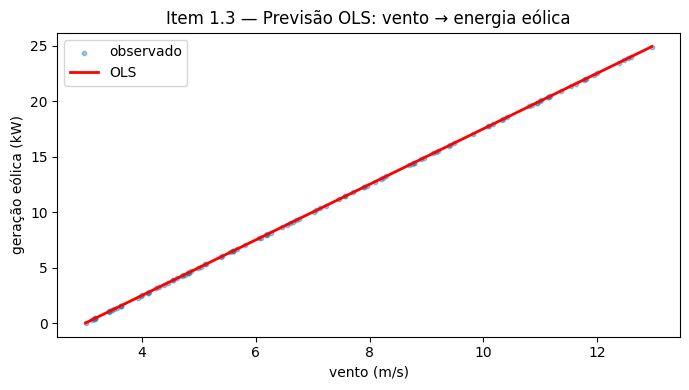

In [5]:
from aurora_siger.operations.prediction import (
    fit_wind_power_model, predict, fit_energy_trend,
)

a, b = fit_wind_power_model(history)
print(f"Modelo eólico ajustado: energia ≈ {a:.2f}·vento + {b:.2f}")

pts = [(w, p) for w, p in zip(history["wind_ms"], history["wind_generation_kw"])
       if p > 0]  # acima do cut-in
xs = [p[0] for p in pts]; ys = [p[1] for p in pts]

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(xs, ys, s=10, alpha=0.4, label="observado")
line_x = [min(xs), max(xs)]
ax.plot(line_x, [predict(a, b, x) for x in line_x], "r-", lw=2, label="OLS")
ax.set_xlabel("vento (m/s)"); ax.set_ylabel("geração eólica (kW)")
ax.set_title("Item 1.3 — Previsão OLS: vento → energia eólica"); ax.legend()
plt.tight_layout(); plt.show()

### O mesmo estimador, segundo uso: slope preditivo

`fit_energy_trend()` reusa a mesma OLS sobre os deltas recentes de energia e
devolve `(slope, predicted_next_delta)`. O slope é o sinal antecipatório que
rebaixa o nível de energia *antes* de a bateria piorar (o salto reativo→preditivo).

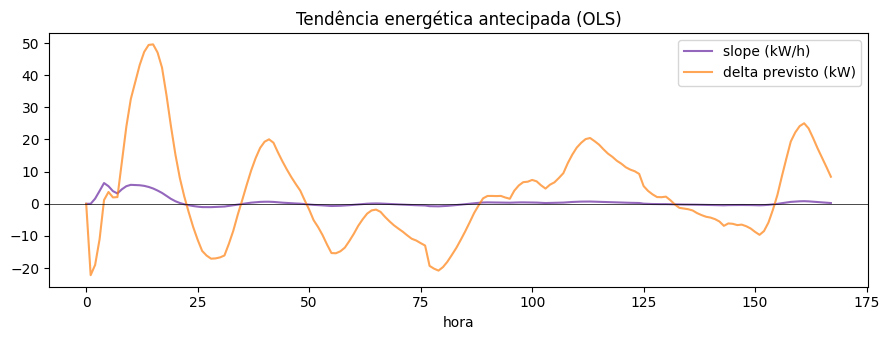

Últimas 48 h → slope=+0.140 kW/h, próximo delta previsto=+5.69 kW


In [6]:
slope = history["slope"]; pred = history["predicted_delta"]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(slope, label="slope (kW/h)", color="tab:purple")
ax.plot(pred, label="delta previsto (kW)", color="tab:orange", alpha=0.7)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("hora"); ax.set_title("Tendência energética antecipada (OLS)")
ax.legend(); plt.tight_layout(); plt.show()

# Demonstração isolada do estimador sobre os últimos deltas:
s, p = fit_energy_trend(deltas[-48:])
print(f"Últimas 48 h → slope={s:+.3f} kW/h, próximo delta previsto={p:+.2f} kW")

## Item 1.4 — Análise energética

Balanço geração×consumo, agregação por sol, *breakdown* por fonte e momentos
críticos — tudo em `analysis.py`.

In [7]:
from aurora_siger.operations import analysis

summary = analysis.summarize_history(history)
print("Resumo da missão:")
for k, v in summary.items():
    print(f"  {k:<22} {v:.1f}" if isinstance(v, float) else f"  {k:<22} {v}")

print("\nBreakdown de geração por fonte:")
for src, d in analysis.generation_breakdown(history).items():
    print(f"  {src:<8} {d['avg_kw']:6.1f} kW  ({d['share'] * 100:4.1f}%)")

print("\nDistribuição de status do balanço:")
for status, c in analysis.status_distribution(history).items():
    print(f"  {status:<10} {c:4d} h")

Resumo da missão:
  total_steps            168
  avg_generation_kw      86.5
  avg_consumption_kw     85.2
  max_generation_kw      145.2
  min_generation_kw      0.0
  storm_hours            63
  alert_hours            7

Breakdown de geração por fonte:
  solar       8.3 kW  ( 9.6%)
  wind        7.2 kW  ( 8.4%)
  nuclear    71.0 kW  (82.0%)

Distribuição de status do balanço:
  risk         93 h
  balanced     29 h
  surplus      46 h


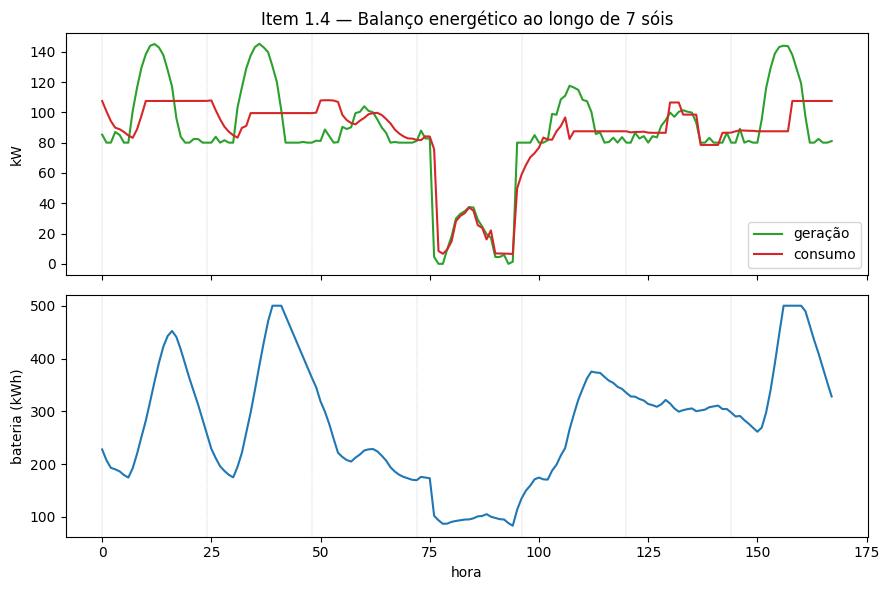

In [8]:
gen = history["total_generation_kw"]; con = history["total_consumption_kw"]
bat = history["battery_charge_kwh"]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax1.plot(gen, label="geração", color="tab:green")
ax1.plot(con, label="consumo", color="tab:red")
ax1.set_ylabel("kW"); ax1.legend()
ax1.set_title("Item 1.4 — Balanço energético ao longo de 7 sóis")
ax2.plot(bat, color="tab:blue")
ax2.set_ylabel("bateria (kWh)"); ax2.set_xlabel("hora")
for s in range(0, n, HOURS_PER_SOL):  # marcas de início de sol
    for ax in (ax1, ax2):
        ax.axvline(s, color="gray", lw=0.3, ls=":")
plt.tight_layout(); plt.show()

In [9]:
print("Agregação por sol:")
print(f"{'sol':>3} {'horas':>5} {'ger.méd':>8} {'cons.méd':>9} {'delta':>7}  regime")
for row in analysis.aggregate_by_sol(history):
    print(f"{row['sol']:>3} {row['hours']:>5} {row['avg_generation_kw']:>8.1f} "
          f"{row['avg_consumption_kw']:>9.1f} {row['avg_delta_kw']:>+7.1f}  {row['regime']}")

cm = analysis.critical_moments(history)
print(f"\nPior déficit:  {cm['worst_deficit']}")
print(f"Maior excedente: {cm['biggest_surplus']}")

Agregação por sol:
sol horas  ger.méd  cons.méd   delta  regime
  0    24    102.6     101.2    +1.4  clear
  1    24    102.3      97.2    +5.1  clear
  2    24     87.6      96.5    -8.9  clear/light
  3    24     30.3      32.6    -2.4  light
  4    24     92.8      83.3    +9.5  clear/light
  5    24     87.9      89.5    -1.6  clear
  6    24    102.0      95.9    +6.1  clear

Pior déficit:  {'sol': 3, 'hour': 4, 'delta_kw': -71.11672228920598, 'storm': 'light'}
Maior excedente: {'sol': 6, 'hour': 12, 'delta_kw': 56.47735674994962, 'storm': 'clear'}


## Fecho — do reativo ao preditivo

A simulação acima é determinística: rodá-la de novo com `seed=42` reproduz cada
número. Sobre esse núcleo, a Fase 3 estratifica o controle em duas camadas
(`power_factor` contínuo + *load shedding* estrutural) e usa a mesma OLS para
**antecipar** tendência, não só reagir a limiares — o tema do ensaio
[`docs/fase-3/reativo-a-preditivo.md`](../../docs/fase-3/reativo-a-preditivo.md).
Para ver tudo isto ao vivo, com 6 abas e eventos de clima/falha: execute `aurora`.